### Implemtation TIBs Bars 

Tick imbalance bars 

$$
T*= \arg \min_{T} ( \theta_T \ge (E_0[T](2P(b_t=1)-1)) 
$$

- T* last index fisnish bar
- $\arg\min$ condition
- $\theta_T$ fact imbalance
- $E_0[T]$ expected size var 
- $(2P(b_t=1)-1)$ media movil de las bars anteriores para bt

$$
E_0[T]=(1-\lambda)T_{i-1} + \lambda E_0[T]_{i-1}
$$

In [464]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports completados")

✓ Imports completados


In [465]:
from pathlib import Path
import sys

cwd = Path().resolve()
for p in [cwd] + list(cwd.parents):
    if (p / "utils").is_dir():
        sys.path.insert(0, str(p))
        break

from utils.download_data_binance import DowloadDataBinance


In [466]:
data_path = '../data/raw'
dowload_data = DowloadDataBinance(data_path)

df = dowload_data.download_trades_binance(
    symbol='BTCUSDT',
    hours=120,  
    max_trades=300000
)

dowload_data.show_info(df)

🔄 Descargando trades de BTCUSDT...
📊 Trades: 200,000 | Iter: 200
✓ Descargados: 200,000 trades
💾 Guardado en: ../data/rawBTCUSDT_trades_20251022_181545.csv

📊 INFORMACIÓN DE LOS DATOS
Total trades: 94,607
Período: 2025-10-17 23:13:53.359000 a 2025-10-18 06:10:34.420000
Duración: 6.9 horas

Primeros 5 trades:
                timestamp      price  quantity  dollar_value
0 2025-10-17 23:13:53.359  106826.26   0.01525   1629.100465
1 2025-10-17 23:13:54.103  106826.27   0.00046     49.140084
2 2025-10-17 23:13:56.339  106826.27   0.00302    322.615335
3 2025-10-17 23:13:56.848  106826.27   0.00068     72.641864
4 2025-10-17 23:13:56.880  106826.26   0.00014     14.955676

Estadísticas:
                           timestamp          price      quantity  \
count                          94607   94607.000000  94607.000000   
mean   2025-10-18 02:36:42.681773056  106780.818420      0.025188   
min       2025-10-17 23:13:53.359000  106322.200000      0.000010   
25%    2025-10-18 00:59:50.084499

In [467]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94607 entries, 0 to 94606
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     94607 non-null  datetime64[ns]
 1   price         94607 non-null  float64       
 2   quantity      94607 non-null  float64       
 3   dollar_value  94607 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 2.9 MB


In [468]:
df.head(5)

,timestamp,price,quantity,dollar_value
0,2025-10-17 23:13:53.359,106826.26,0.01525,1629.100465
1,2025-10-17 23:13:54.103,106826.27,0.00046,49.140084
2,2025-10-17 23:13:56.339,106826.27,0.00302,322.615335
3,2025-10-17 23:13:56.848,106826.27,0.00068,72.641864
4,2025-10-17 23:13:56.880,106826.26,0.00014,14.955676


In [ ]:
# get ticket directions 

def update_prob_buy(bar_b_t, current_prob, lambda_):
    recent_prob = (bar_b_t == 1).mean()
    # Suavizado exponencial doble para mayor estabilidad
    return (1 - lambda_**2) * recent_prob + lambda_**2 * current_prob


def get_tick_directions(df: pd.DataFrame) -> pd.Series:
    price_diff = df['price'].diff() # firence previus and acutal price
    b_t = np.sign(price_diff) # get a sign 
    
    b_t = b_t.replace(0, np.nan).ffill().fillna(1) # 0 -> Nan, fill series valid value, first (1)
    return b_t

def tick_imbalance_bars(
    df: pd.DataFrame, exp_lambda = 0.9, init_exp_T = 1600, init_p_buy=0.5) -> pd.DataFrame:
    df = df.copy()
    df['b_t'] = get_tick_directions(df)
    
    # initial 
    E_T = init_exp_T
    prob_buy = init_p_buy
    bars = []
    tick_imbalance = 0
    tick_count = 0 
    last_index = 0 
    
    for i in range(1, len(df)):
        tick_count += 1
        tick_imbalance += df.loc[i, 'b_t'] 
        
        # stop condition 
        thereshold = E_T * abs(2 * prob_buy -1) 
        # Añade un mínimo de ticks para evitar barras muy cortas
        MIN_TICKS = 20
        if abs(tick_imbalance) >= thereshold and tick_count >= MIN_TICKS:
            # Formar barra
            bar = df.iloc[last_index:i+1]
            bars.append({
                'open_time': bar['timestamp'].iloc[0],
                'close_time': bar['timestamp'].iloc[-1],
                'open': bar['price'].iloc[0],
                'high': bar['price'].max(),
                'low': bar['price'].min(),
                'close': bar['price'].iloc[-1],
                'n_ticks': len(bar),
                'volume': bar['quantity'].sum(),
                'dollar_value': bar['dollar_value'].sum(),
            })
            
            # update waited 
            E_T =(1 - exp_lambda) * len(bar) + exp_lambda * E_T 
            prob_buy = update_prob_buy(bar['b_t'], prob_buy, exp_lambda)

            
            # Reset
            tick_imbalance = 0 
            tick_count = 0 
            last_index = i + 1
    
    bars_df = pd.DataFrame(bars)    
    return bars_df

In [478]:
tib_bars = tick_imbalance_bars(df)
print(tib_bars.head(5).sort_index())


                open_time              close_time       open       high  \
0 2025-10-17 23:13:53.359 2025-10-17 23:14:04.397  106826.26  106829.42   
1 2025-10-17 23:14:04.604 2025-10-17 23:19:03.054  106829.42  106863.83   
2 2025-10-17 23:19:03.055 2025-10-17 23:23:20.079  106862.01  106878.36   
3 2025-10-17 23:23:20.496 2025-10-17 23:28:04.975  106722.84  106759.60   
4 2025-10-17 23:28:05.386 2025-10-17 23:29:08.681  106759.60  106759.60   

         low      close  n_ticks    volume  dollar_value  
0  106826.26  106829.42       21   0.71998  7.691474e+04  
1  106769.60  106863.83      867  15.15271  1.618727e+06  
2  106722.83  106722.83      912  17.88688  1.910438e+06  
3  106710.11  106759.60      810  11.69042  1.247667e+06  
4  106709.83  106709.84      357   4.57590  4.883854e+05  


In [479]:
print('num bars:',len(tib_bars))

num bars: 899


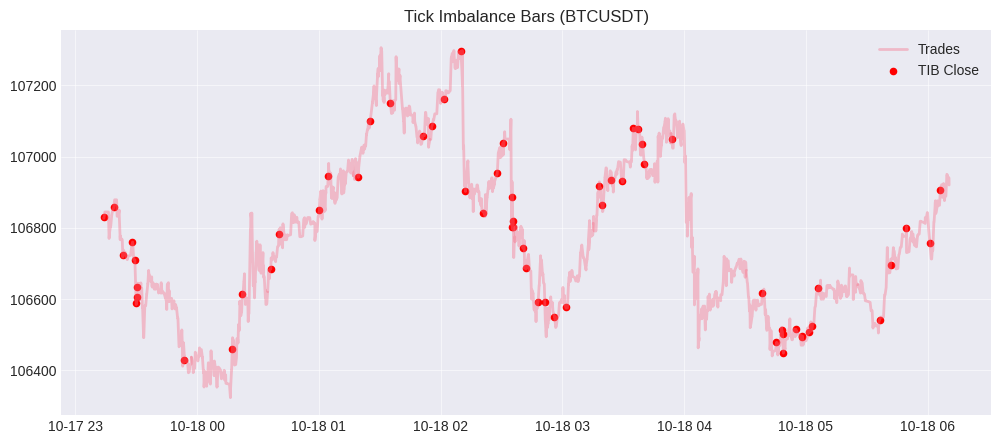

In [472]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['price'], alpha=0.4, label='Trades')
plt.scatter(tib_bars['close_time'], tib_bars['close'], color='red', s=20, label='TIB Close')
plt.legend()
plt.title('Tick Imbalance Bars (BTCUSDT)')
plt.show()


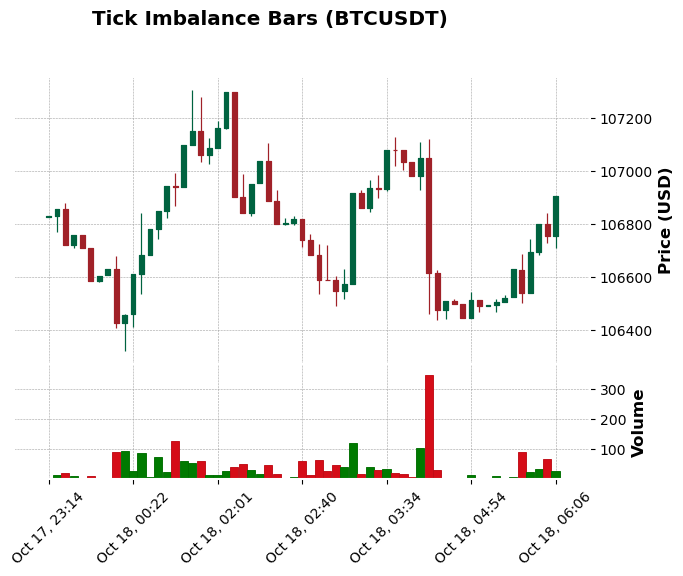

In [473]:
import mplfinance as mpf

tib_bars.set_index('close_time', inplace=True)

mpf.plot(
    tib_bars,
    type='candle',
    style='charles',
    volume=True,
    title='Tick Imbalance Bars (BTCUSDT)',
    ylabel='Price (USD)',
    ylabel_lower='Volume',
)
